# 1.3. Сбор данных с различных источников (Лекция_3)


ETL-процесс: Extract, Transform, Load — базовые понятия. Web-scraping и API: инструменты (Requests, BeautifulSoup, Postman) и нюансы юридической стороны. Парсинг файлов: чтение данных из файлов (CSV, Excel, JSON), первичная фильтрация.


Задание:

## 1. Чтение и обработка CSV-файлов

Цель: Прочитать файл формата CSV, содержащий данные о студентах университета (ФИО, возраст, специальность), и построить отчёт по среднему возрасту студентов разных факультетов.

- Фамилия,Имя,Возраст,Специальность
- Иванов,Александр,21,Программирование
- Петрова,Анна,20,Экономика
- Кузнецов,Сергей,22,Биология
- Сергеев,Дмитрий,21,Программирование
- Романова,Елена,20,Экономика
- Николаев,Павел,23,Биология

Для каждой специальности определить средний возраст студентов и вывести результат в консоль.



In [ ]:
import csv

# Данные для теста
data = """Фамилия,Имя,Возраст,Специальность
Иванов,Александр,21,Программирование
Петрова,Анна,20,Экономика
Кузнецов,Сергей,22,Биология
Сергеев,Дмитрий,21,Программирование
Романова,Елена,20,Экономика
Николаев,Павел,23,Биология"""

# Сохраняем данные в CSV-файл
with open('students.csv', 'w', newline='', encoding='utf-8') as file:
    file.write(data)

# Читаем и обрабатываем CSV-файл
specialty_age_sum = {}  # Словарь для сумм возрастов по специальностям
specialty_count = {}     # Словарь для счёта студентов по специальностям

with open('students.csv', 'r', newline='', encoding='utf-8') as file:

      # Ваш код здесь...

# Вывод среднего возраста по специальностям
for spec, total_age in specialty_age_sum.items():
    avg_age = total_age / specialty_count[spec]
    print(f"Средний возраст студентов по специальности '{spec}' составляет {avg_age:.2f} лет")

Решение:

In [ ]:
import csv

# Данные для теста
data = """Фамилия,Имя,Возраст,Специальность
Иванов,Александр,21,Программирование
Петрова,Анна,20,Экономика
Кузнецов,Сергей,22,Биология
Сергеев,Дмитрий,21,Программирование
Романова,Елена,20,Экономика
Николаев,Павел,23,Биология"""

# Сохраняем данные в CSV-файл
with open('students.csv', 'w', newline='', encoding='utf-8') as file:
    file.write(data)

# Читаем и обрабатываем CSV-файл
specialty_age_sum = {}  # Словарь для сумм возрастов по специальностям
specialty_count = {}     # Словарь для счёта студентов по специальностям

with open('students.csv', 'r', newline='', encoding='utf-8') as file:
    reader = csv.DictReader(file)
    for row in reader:
        specialty = row["Специальность"]
        age = int(row["Возраст"])

        if specialty not in specialty_age_sum:
            specialty_age_sum[specialty] = 0
            specialty_count[specialty] = 0

        specialty_age_sum[specialty] += age
        specialty_count[specialty] += 1

# Вывод среднего возраста по специальностям
for spec, total_age in specialty_age_sum.items():
    avg_age = total_age / specialty_count[spec]
    print(f"Средний возраст студентов по специальности '{spec}' составляет {avg_age:.2f} лет")

Средний возраст студентов по специальности 'Программирование' составляет 21.00 лет
Средний возраст студентов по специальности 'Экономика' составляет 20.00 лет
Средний возраст студентов по специальности 'Биология' составляет 22.50 лет


-------------------------------------------------------------

## 2. Сбор данных с веб-страницы (web scraping)

Цель: Спарсить страницу с рейтингом фильмов и собрать первую десятку лучших фильмов вместе с их оценками.

Пример HTML-разметки страницы:

In [ ]:
'''
<div class="film-list">
    <h2>Рейтинг фильмов:</h2>
    <ul>
        <li><span class="title">Фильм №1</span> (<span class="rating">9.5</span>)</li>
        <li><span class="title">Фильм №2</span> (<span class="rating">9.0</span>)</li>
        <!-- Остальные фильмы -->
    </ul>
</div>
'''

Собрать первые десять фильмов и их оценки с помощью инструмента вроде BeautifulSoup и сохранить их в списке кортежей вида (фильм, оценка).

Задание:

In [ ]:
from bs4 import BeautifulSoup

# Пример HTML-данных
html_doc = """
<div class="film-list">
    <h2>Рейтинг фильмов:</h2>
    <ul>
        <li><span class="title">Фильм №1</span> (<span class="rating">9.5</span>)</li>
        <li><span class="title">Фильм №2</span> (<span class="rating">9.0</span>)</li>
        <li><span class="title">Фильм №3</span> (<span class="rating">8.5</span>)</li>
        <li><span class="title">Фильм №4</span> (<span class="rating">8.0</span>)</li>
        <li><span class="title">Фильм №5</span> (<span class="rating">7.5</span>)</li>
    </ul>
</div>
"""

soup = BeautifulSoup(html_doc, 'html.parser')

# Находим блок с фильмами

# Ваш код здесь...

Решение:

In [ ]:
from bs4 import BeautifulSoup

# Пример HTML-данных
html_doc = """
<div class="film-list">
    <h2>Рейтинг фильмов:</h2>
    <ul>
        <li><span class="title">Фильм №1</span> (<span class="rating">9.5</span>)</li>
        <li><span class="title">Фильм №2</span> (<span class="rating">9.0</span>)</li>
        <li><span class="title">Фильм №3</span> (<span class="rating">8.5</span>)</li>
        <li><span class="title">Фильм №4</span> (<span class="rating">8.0</span>)</li>
        <li><span class="title">Фильм №5</span> (<span class="rating">7.5</span>)</li>
    </ul>
</div>
"""

soup = BeautifulSoup(html_doc, 'html.parser')

# Находим блок с фильмами
film_list = soup.find(class_="film-list").find_all("li")
films_and_ratings = []  # Здесь будем хранить пары (фильм, оценка)

for film_item in film_list:
    title = film_item.find(class_="title").text.strip()
    rating = film_item.find(class_="rating").text.strip()
    films_and_ratings.append((title, rating))

# Отображаем первые 5 фильмов и их рейтинги
for i, (title, rating) in enumerate(films_and_ratings[:5]):
    print(f"{i+1}. Фильм: {title}, Рейтинг: {rating}")

1. Фильм: Фильм №1, Рейтинг: 9.5
2. Фильм: Фильм №2, Рейтинг: 9.0
3. Фильм: Фильм №3, Рейтинг: 8.5
4. Фильм: Фильм №4, Рейтинг: 8.0
5. Фильм: Фильм №5, Рейтинг: 7.5


-------------------------------------------------------------------

## 3. Чтение и работа с файлами формата Excel (.xlsx)

Цель: Открыть файл Excel, содержащий таблицу зарплат сотрудников, сгруппировать зарплаты по должностям и посчитать среднее значение зарплаты для каждой должности.

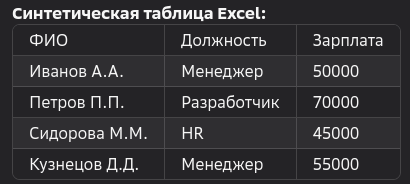

Подсчитать средние значения зарплат по каждому типу должности и вывести итоговую таблицу.

Задание:

In [ ]:
import pandas as pd

# Синтетические данные для примера
data = {'ФИО': ['Иванов А.А.', 'Петров П.П.', 'Сидорова М.М.', 'Кузнецов Д.Д.'],
        'Должность': ['Менеджер', 'Разработчик', 'HR', 'Менеджер'],
        'Зарплата': [50000, 70000, 45000, 55000]}

# Создаем DataFrame

  # Ваш код здесь...

# Результат отображается в удобной форме
print(result)

Решение:

In [ ]:
import pandas as pd

# Синтетические данные для примера
data = {'ФИО': ['Иванов А.А.', 'Петров П.П.', 'Сидорова М.М.', 'Кузнецов Д.Д.'],
        'Должность': ['Менеджер', 'Разработчик', 'HR', 'Менеджер'],
        'Зарплата': [50000, 70000, 45000, 55000]}

# Создаем DataFrame
df = pd.DataFrame(data)

# Сохраняем в Excel
df.to_excel('salary.xlsx', index=False)

# Теперь загрузим сохраненный файл обратно и выполним расчеты
loaded_df = pd.read_excel('salary.xlsx')

# Группировка по должностям и расчет среднего значения зарплат
result = loaded_df.groupby('Должность')['Зарплата'].mean().reset_index()

# Результат отображается в удобной форме
print(result)

     Должность  Зарплата
0           HR   45000.0
1     Менеджер   52500.0
2  Разработчик   70000.0


-------------------------------------------------------------

## 4. Трансформация данных JSON в CSV

Цель: Преобразовать данные формата JSON, полученные от API сервиса новостей, в файл CSV для последующего анализа.

Пример входящего JSON:

In [ ]:
[
    {
        "title": "Новости №1",
        "author": "Автор №1",
        "published_at": "2023-01-01T12:00:00Z"
    },
    {
        "title": "Новости №2",
        "author": "Автор №2",
        "published_at": "2023-01-02T14:00:00Z"
    }
]

Сохранить полученный JSON в виде таблицы CSV с тремя колонками: "Заголовок", "Автор", "Дата публикации".

Задание:

In [ ]:
import json
import csv

# Пример JSON-данных
news_json = [
    {
        "title": "Новости №1",
        "author": "Автор №1",
        "published_at": "2023-01-01T12:00:00Z"
    },
    {
        "title": "Новости №2",
        "author": "Автор №2",
        "published_at": "2023-01-02T14:00:00Z"
    }
]

# Конвертируем JSON в CSV

  # Ваш код здесь...

# Проверка результата
with open('news.csv', 'r', newline='', encoding='utf-8') as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        print(', '.join(row))

Решение:

In [ ]:
import json
import csv

# Пример JSON-данных
news_json = [
    {
        "title": "Новости №1",
        "author": "Автор №1",
        "published_at": "2023-01-01T12:00:00Z"
    },
    {
        "title": "Новости №2",
        "author": "Автор №2",
        "published_at": "2023-01-02T14:00:00Z"
    }
]

# Конвертируем JSON в CSV
fieldnames = ["Заголовок", "Автор", "Дата публикации"]

with open('news.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()

    for item in news_json:
        writer.writerow({
            "Заголовок": item["title"],
            "Автор": item["author"],
            "Дата публикации": item["published_at"]
        })

# Проверка результата
with open('news.csv', 'r', newline='', encoding='utf-8') as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        print(', '.join(row))

Заголовок, Автор, Дата публикации
Новости №1, Автор №1, 2023-01-01T12:00:00Z
Новости №2, Автор №2, 2023-01-02T14:00:00Z


------------------------------------------------------------

## 5. Работа с файлами формата JSON

Цель: Прочитать файл формата JSON, содержащий информацию о фильмах кинотеатра (название фильма, жанры, продолжительность в минутах), и вывести все фильмы длительностью менее двух часов (менее 120 минут).

Синтетический набор данных:

In [ ]:
[
    {"title": "Матрица", "genres": ["Action"], "duration_minutes": 136},
    {"title": "Интерстеллар", "genres": ["Sci-Fi"], "duration_minutes": 169},
    {"title": "Форрест Гамп", "genres": ["Drama"], "duration_minutes": 142},
    {"title": "Один дома", "genres": ["Comedy"], "duration_minutes": 103},
    {"title": "Начало", "genres": ["Thriller"], "duration_minutes": 148}
]

Прочитать файл формата JSON и вывести названия всех фильмов, длительность которых меньше 120 минут.

Задание:

In [ ]:
import json

# Исходные данные
movies_json = '''
[
    {"title": "Матрица", "genres": ["Action"], "duration_minutes": 136},
    {"title": "Интерстеллар", "genres": ["Sci-Fi"], "duration_minutes": 169},
    {"title": "Форрест Гамп", "genres": ["Drama"], "duration_minutes": 142},
    {"title": "Один дома", "genres": ["Comedy"], "duration_minutes": 103},
    {"title": "Начало", "genres": ["Thriller"], "duration_minutes": 148}
]
'''

# Переводим строку JSON в словарь Python

  # Ваш код здесь...

Решение:

In [ ]:
import json

# Исходные данные
movies_json = '''
[
    {"title": "Матрица", "genres": ["Action"], "duration_minutes": 136},
    {"title": "Интерстеллар", "genres": ["Sci-Fi"], "duration_minutes": 169},
    {"title": "Форрест Гамп", "genres": ["Drama"], "duration_minutes": 142},
    {"title": "Один дома", "genres": ["Comedy"], "duration_minutes": 103},
    {"title": "Начало", "genres": ["Thriller"], "duration_minutes": 148}
]
'''

# Переводим строку JSON в словарь Python
movies_data = json.loads(movies_json)

# Проходим по списку фильмов и выбираем фильмы короче 120 минут
short_movies = [movie["title"] for movie in movies_data if movie["duration_minutes"] < 120]

# Выводим результат
print("Фильмы продолжительностью менее 120 минут:")
for movie_title in short_movies:
    print(movie_title)

Фильмы продолжительностью менее 120 минут:
Один дома
